# 🚧 YOLOv5m — Road Damage + Garbage Detection

**Classes:** crack · damage · pothole · pothole_water · pothole_water_m · garbage  
**Model:** YOLOv5m | **Epochs:** 50 | **Dataset:** combined_dataset (zipped upload)

---
### ⚠️ Before running anything:
1. Go to **Runtime → Change runtime type → T4 GPU** and save.
2. Run cells **one at a time, top to bottom**. Never skip a cell.
3. Have your **`combined_dataset.zip`** ready to upload when Cell 3 asks.

---
## CELL 1 — Verify GPU is available

In [1]:
# ── CELL 1: GPU CHECK ──────────────────────────────────────────────────────
# Always confirm a GPU is assigned before doing anything else.
# If you see 'No GPU' stop here and change runtime type.

import subprocess

result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)

if result.returncode == 0:
    print(result.stdout)
    print('✅ GPU is available — good to go!')
else:
    print('❌ No GPU detected!')
    print('→ Go to Runtime > Change runtime type > T4 GPU and re-run.')

Sat Apr 11 10:30:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## CELL 2 — Clone YOLOv5 & install dependencies

In [2]:
# ── CELL 2: CLONE YOLOV5 + INSTALL REQUIREMENTS ───────────────────────────
# Clones the official Ultralytics YOLOv5 repo into /content/yolov5
# and installs every package it needs (torch is already on Colab).

import os

# Clone only if not already cloned (safe to re-run)
if not os.path.exists('/content/yolov5'):
    !git clone https://github.com/ultralytics/yolov5.git /content/yolov5
    print('✅ YOLOv5 cloned.')
else:
    print('ℹ️  /content/yolov5 already exists — skipping clone.')

# Install Python dependencies listed in YOLOv5s requirements file
%pip install -q -r /content/yolov5/requirements.txt

print('\n✅ All dependencies installed.')

Cloning into '/content/yolov5'...
remote: Enumerating objects: 17851, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 17851 (delta 30), reused 9 (delta 9), pack-reused 17808 (from 3)
Receiving objects: 100% (17851/17851), 17.00 MiB | 20.53 MiB/s, done.
Resolving deltas: 100% (12169/12169), done.
✅ YOLOv5 cloned.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 9.7 MB/s eta 0:00:00

✅ All dependencies installed.


---
## CELL 3 — Upload & extract `combined_dataset.zip`

> **What to do:** Run this cell → a file picker will appear → select your `combined_dataset.zip` → wait for extraction to finish.

In [3]:
# ── CELL 3: UPLOAD & UNZIP DATASET ────────────────────────────────────────
# google.colab.files.upload() opens a file picker in the browser.
# The zip is extracted into /content/combined_dataset/

import os
import zipfile
from google.colab import files

DATASET_ZIP_NAME  = 'combined_dataset.zip'          # ← must match your zip filename exactly
EXTRACT_DIR       = '/content/'                      # extracts to /content/combined_dataset/
DATASET_DIR       = '/content/combined_dataset'

# ── Upload ────────────────────────────────────────────────────────────────
print('📂 File picker opening — select combined_dataset.zip ...')
uploaded = files.upload()   # browser dialog appears here

# Confirm the right file was uploaded
if DATASET_ZIP_NAME not in uploaded:
    raise FileNotFoundError(
        f'Expected "{DATASET_ZIP_NAME}" but got: {list(uploaded.keys())}\n'
        f'Rename your zip to "{DATASET_ZIP_NAME}" and re-run this cell.'
    )

print(f'\n✅ Upload complete: {DATASET_ZIP_NAME} ({list(uploaded.values())[0].__class__.__name__})')

# ── Extract ───────────────────────────────────────────────────────────────
print(f'\n📦 Extracting to {EXTRACT_DIR} ...')
with zipfile.ZipFile(DATASET_ZIP_NAME, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

print('✅ Extraction complete.')

# ── Quick folder check ────────────────────────────────────────────────────
for split in ['train', 'valid', 'test']:
    img_dir   = os.path.join(DATASET_DIR, split, 'images')
    label_dir = os.path.join(DATASET_DIR, split, 'labels')
    imgs   = len(os.listdir(img_dir))   if os.path.exists(img_dir)   else 'MISSING'
    labels = len(os.listdir(label_dir)) if os.path.exists(label_dir) else 'MISSING'
    print(f'  [{split}]  images: {imgs}  |  labels: {labels}')

📂 File picker opening — select combined_dataset.zip ...


Saving combined_dataset.zip to combined_dataset.zip

✅ Upload complete: combined_dataset.zip (bytes)

📦 Extracting to /content/ ...
✅ Extraction complete.
  [train]  images: MISSING  |  labels: MISSING
  [valid]  images: MISSING  |  labels: MISSING
  [test]  images: MISSING  |  labels: MISSING


In [8]:
# ── DIAGNOSTIC: Find where the dataset actually extracted to ──────────────
import os

# Search for where 'images' folder ended up after extraction
print("🔍 Searching for extracted structure...\n")
for root, dirs, files in os.walk('/content'):
    # Skip the yolov5 repo to keep output clean
    if 'yolov5' in root:
        continue
    for d in dirs:
        if d in ['images', 'labels', 'train', 'valid', 'test']:
            print(os.path.join(root, d))

🔍 Searching for extracted structure...

/content/combined_dataset/train
/content/combined_dataset/test
/content/combined_dataset/valid
/content/combined_dataset/train/images
/content/combined_dataset/train/labels
/content/combined_dataset/test/images
/content/combined_dataset/test/labels
/content/combined_dataset/valid/images
/content/combined_dataset/valid/labels


In [6]:
# ── FULL CONTENT SCAN ─────────────────────────────────────────────────────
import os

print("Everything under /content (excluding yolov5 and .git):\n")
for root, dirs, files in os.walk('/content'):
    # Skip noisy folders
    dirs[:] = [d for d in dirs if d not in ['.git', '__pycache__', 'node_modules', 'yolov5']]
    level = root.replace('/content', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:   # only show files at top 3 levels to avoid spam
        for f in files[:5]:   # max 5 files per folder
            print(f'{indent}  {f}')
        if len(files) > 5:
            print(f'{indent}  ... and {len(files)-5} more files')

Everything under /content (excluding yolov5 and .git):

content/
  combined_dataset\train\labels\ds1_444_jpg.rf.c924be3850b1466729cdceeadc88b94a.txt
  combined_dataset\train\images\ds1_181_jpg.rf.6708edb074322943c171e3237efee114.jpg
  combined_dataset\train\labels\ds1_110_jpg.rf.605dd7a7e56cbc64562152dbd4e6203d.txt
  combined_dataset\train\images\ds2_img1980_jpg.rf.87cce4c3185a1ffa11df99fb59a277d3.jpg
  combined_dataset\train\images\ds1_266_jpg.rf.4463535f64ca7fb0b7d000c0d58f744e.jpg
  ... and 4536 more files
  .config/
    active_config
    gce
    config_sentinel
    hidden_gcloud_config_universe_descriptor_data_cache_configs.db
    .last_opt_in_prompt.yaml
    ... and 3 more files
    configurations/
      config_default
    logs/
      2026.03.30/
  .ipynb_checkpoints/
  sample_data/
    README.md
    anscombe.json
    california_housing_train.csv
    mnist_train_small.csv
    california_housing_test.csv
    ... and 1 more files


In [7]:
# ── FIX: Reconstruct proper folder structure from backslash filenames ──────
import os, shutil

CONTENT = '/content'
TARGET  = '/content/combined_dataset'

# Find all files that have backslashes in their name (the broken ones)
broken_files = []
for f in os.listdir(CONTENT):
    if '\\' in f:
        broken_files.append(f)

print(f"Found {len(broken_files)} files with backslash paths. Reconstructing...\n")

moved   = 0
errors  = 0

for flat_name in broken_files:
    # flat_name looks like: "combined_dataset\train\images\ds1_foo.jpg"
    # Convert backslashes to forward slashes to get proper relative path
    rel_path    = flat_name.replace('\\', '/')          # combined_dataset/train/images/ds1_foo.jpg

    # Strip the leading "combined_dataset/" since target IS combined_dataset
    parts       = rel_path.split('/')                   # ['combined_dataset', 'train', 'images', 'ds1_foo.jpg']
    if parts[0] == 'combined_dataset':
        parts = parts[1:]                               # ['train', 'images', 'ds1_foo.jpg']

    dst_path    = os.path.join(TARGET, *parts)          # /content/combined_dataset/train/images/ds1_foo.jpg
    dst_dir     = os.path.dirname(dst_path)

    src_path    = os.path.join(CONTENT, flat_name)

    try:
        os.makedirs(dst_dir, exist_ok=True)
        shutil.move(src_path, dst_path)
        moved += 1
    except Exception as e:
        print(f"  ❌ Error moving {flat_name}: {e}")
        errors += 1

print(f"✅ Moved:  {moved} files")
print(f"❌ Errors: {errors} files\n")

# ── Verify final structure ────────────────────────────────────────────────
print("── Verification ─────────────────────────────────────────────")
for split in ['train', 'valid', 'test']:
    img_dir   = os.path.join(TARGET, split, 'images')
    label_dir = os.path.join(TARGET, split, 'labels')
    imgs   = len(os.listdir(img_dir))   if os.path.exists(img_dir)   else 'MISSING'
    labels = len(os.listdir(label_dir)) if os.path.exists(label_dir) else 'MISSING'
    print(f"  [{split}]  images: {imgs}  |  labels: {labels}")

# ── Also move data.yaml if it got flattened ───────────────────────────────
yaml_flat = os.path.join(CONTENT, 'combined_dataset\\data.yaml')
yaml_dst  = os.path.join(TARGET, 'data.yaml')
if os.path.exists(yaml_flat):
    shutil.move(yaml_flat, yaml_dst)
    print(f"\n✅ data.yaml moved to {yaml_dst}")
elif os.path.exists(yaml_dst):
    print(f"\n✅ data.yaml already in correct location")
else:
    print(f"\n⚠️  data.yaml not found — you may need to recreate it")

print("\n✅ Done! Now re-run Cell 4 (yaml fix) and continue from there.")

Found 4540 files with backslash paths. Reconstructing...

✅ Moved:  4540 files
❌ Errors: 0 files

── Verification ─────────────────────────────────────────────
  [train]  images: 1865  |  labels: 1865
  [valid]  images: 186  |  labels: 186
  [test]  images: 217  |  labels: 217

✅ data.yaml already in correct location

✅ Done! Now re-run Cell 4 (yaml fix) and continue from there.


---
## CELL 4 — Fix `data.yaml` paths for Colab

> The `path:` in your yaml points to your Windows machine. This cell rewrites it to the correct Colab path.

In [9]:
# ── CELL 4: REWRITE data.yaml WITH CORRECT COLAB PATHS ────────────────────
# Your local yaml has a Windows absolute path which won't work on Colab.
# We rewrite the file in-place with the correct /content/... path.

import yaml

YAML_PATH = '/content/combined_dataset/data.yaml'

# Read current yaml
with open(YAML_PATH, 'r') as f:
    data = yaml.safe_load(f)

# Overwrite only the path-related keys
data['path']  = '/content/combined_dataset'
data['train'] = 'train/images'
data['val']   = 'valid/images'
data['test']  = 'test/images'

# Write back
with open(YAML_PATH, 'w') as f:
    yaml.dump(data, f, default_flow_style=False, sort_keys=False)

# Print final yaml so you can visually confirm it
print('✅ data.yaml updated. Final contents:\n')
with open(YAML_PATH, 'r') as f:
    print(f.read())

✅ data.yaml updated. Final contents:

path: /content/combined_dataset
train: train/images
val: valid/images
test: test/images
nc: 6
names:
- crack
- damage
- pothole
- pothole_water
- pothole_water_m
- garbage



---
## CELL 5 — Validate dataset integrity (labels, classes, alignment)

> This is your **'is the dataset loaded correctly?'** cell. Read every line of output before proceeding.

In [10]:
# ── CELL 5: FULL DATASET VALIDATION ───────────────────────────────────────
# Checks:
#   (a) All splits exist with correct subfolder structure
#   (b) Every image has a paired label (alignment check)
#   (c) Class IDs in labels are all within [0, nc-1]
#   (d) Annotation count per class — confirms garbage was remapped correctly

import os
import yaml

DATASET_DIR = '/content/combined_dataset'
YAML_PATH   = '/content/combined_dataset/data.yaml'
IMG_EXTS    = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)

nc    = cfg['nc']
names = cfg['names']

print(f'📋 data.yaml → nc={nc}, classes={names}\n')
print('=' * 60)

total_errors = 0

for split in ['train', 'valid', 'test']:
    img_dir   = os.path.join(DATASET_DIR, split, 'images')
    label_dir = os.path.join(DATASET_DIR, split, 'labels')

    print(f'\n[{split.upper()}]')

    # ── (a) Folder existence ─────────────────────────────────────────────
    if not os.path.exists(img_dir):
        print(f'  ❌ images folder missing: {img_dir}')
        total_errors += 1
        continue
    if not os.path.exists(label_dir):
        print(f'  ❌ labels folder missing: {label_dir}')
        total_errors += 1
        continue

    img_files   = {p for p in os.listdir(img_dir)   if os.path.splitext(p)[1].lower() in IMG_EXTS}
    label_files = {p for p in os.listdir(label_dir) if p.endswith('.txt')}
    img_stems   = {os.path.splitext(p)[0] for p in img_files}
    label_stems = {os.path.splitext(p)[0] for p in label_files}

    print(f'  Images : {len(img_files)}')
    print(f'  Labels : {len(label_files)}')

    # ── (b) Alignment check ───────────────────────────────────────────────
    orphan_imgs   = img_stems - label_stems
    orphan_labels = label_stems - img_stems
    if orphan_imgs:
        print(f'  ⚠️  {len(orphan_imgs)} images have NO label: {list(orphan_imgs)[:3]}')
        total_errors += len(orphan_imgs)
    else:
        print(f'  ✅ Alignment OK — every image has a label')
    if orphan_labels:
        print(f'  ⚠️  {len(orphan_labels)} labels have NO image: {list(orphan_labels)[:3]}')
        total_errors += len(orphan_labels)

    # ── (c & d) Class ID validation + count ──────────────────────────────
    class_counts  = {i: 0 for i in range(nc)}
    invalid_lines = []
    total_boxes   = 0

    for lf in label_files:
        lpath = os.path.join(label_dir, lf)
        with open(lpath) as f:
            for lineno, line in enumerate(f, 1):
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                cls = int(parts[0])
                if cls < 0 or cls >= nc:
                    invalid_lines.append(f'{lf}:line{lineno} → class {cls}')
                    total_errors += 1
                else:
                    class_counts[cls] += 1
                total_boxes += 1

    print(f'  Total annotations: {total_boxes}')
    print(f'  Class distribution:')
    for cls_id, count in class_counts.items():
        bar    = '█' * min(30, count // max(1, total_boxes // 30))
        status = '✅' if count > 0 else '⚠️ ZERO'
        print(f'    {status} class {cls_id} ({names[cls_id]:>16s}): {count:>5}  {bar}')

    if invalid_lines:
        print(f'  ❌ Invalid class IDs found:')
        for il in invalid_lines[:5]:
            print(f'     {il}')
    else:
        print(f'  ✅ All class IDs are valid (within 0–{nc-1})')

print('\n' + '=' * 60)
if total_errors == 0:
    print('\n🎉 Dataset validation PASSED — safe to train!')
else:
    print(f'\n❌ Validation found {total_errors} issue(s) — fix before training!')

📋 data.yaml → nc=6, classes=['crack', 'damage', 'pothole', 'pothole_water', 'pothole_water_m', 'garbage']


[TRAIN]
  Images : 1865
  Labels : 1865
  ✅ Alignment OK — every image has a label
  Total annotations: 3885
  Class distribution:
    ✅ class 0 (           crack):   141  █
    ✅ class 1 (          damage):   450  ███
    ✅ class 2 (         pothole):   744  █████
    ✅ class 3 (   pothole_water):   903  ███████
    ✅ class 4 ( pothole_water_m):   141  █
    ✅ class 5 (         garbage):  1506  ███████████
  ✅ All class IDs are valid (within 0–5)

[VALID]
  Images : 186
  Labels : 186
  ✅ Alignment OK — every image has a label
  Total annotations: 494
  Class distribution:
    ✅ class 0 (           crack):    17  █
    ✅ class 1 (          damage):    49  ███
    ✅ class 2 (         pothole):    45  ██
    ✅ class 3 (   pothole_water):    73  ████
    ✅ class 4 ( pothole_water_m):     8  
    ✅ class 5 (         garbage):   302  ██████████████████
  ✅ All class IDs are valid (wi

---
## CELL 6 — Visualise sample images with bounding boxes (sanity check)

> Plots 6 random training images with their bounding boxes drawn. Visually confirm boxes sit correctly on objects.

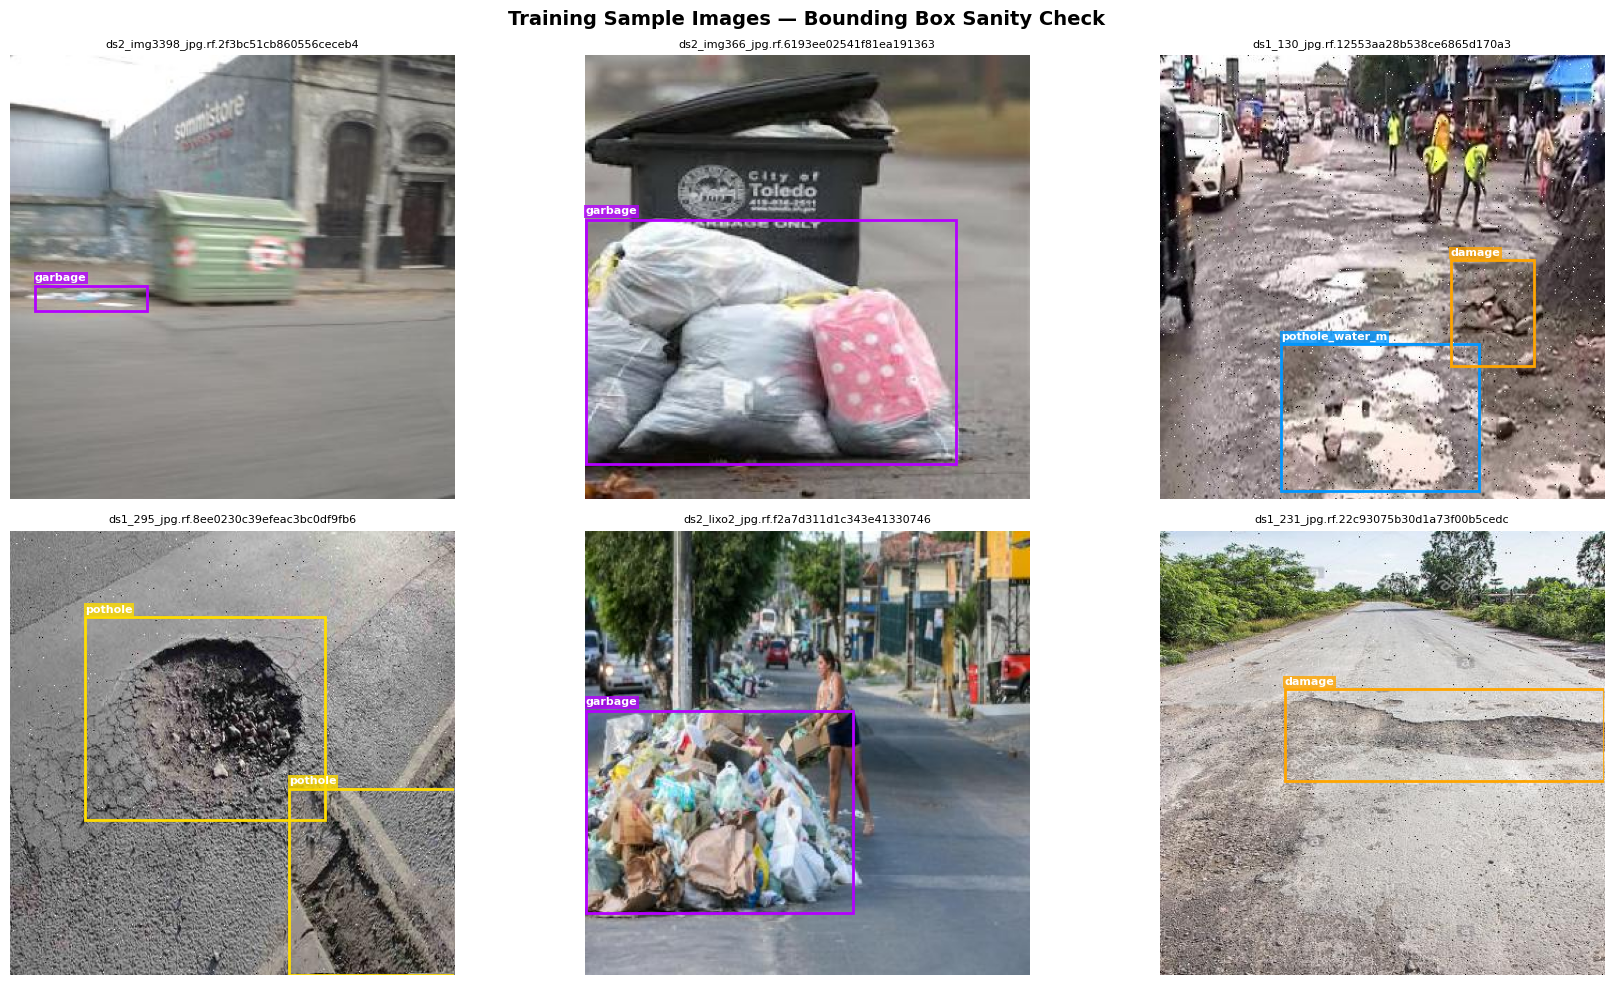

✅ If boxes sit correctly on objects above, dataset is confirmed good.


In [11]:
# ── CELL 6: VISUAL SANITY CHECK ───────────────────────────────────────────
# Draws bounding boxes from the label files on top of their images.
# If boxes look wrong (misplaced / wrong class colour), stop and investigate.

import os, random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image

DATASET_DIR = '/content/combined_dataset'
CLASS_NAMES = ['crack', 'damage', 'pothole', 'pothole_water', 'pothole_water_m', 'garbage']
COLORS = [
    (255,  80,  80),   # crack          → red
    (255, 165,   0),   # damage         → orange
    (255, 220,   0),   # pothole        → yellow
    (  0, 200, 100),   # pothole_water  → green
    (  0, 150, 255),   # pothole_water_m→ blue
    (180,   0, 255),   # garbage        → purple
]
N_SAMPLES   = 6
IMG_EXTS    = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

img_dir   = os.path.join(DATASET_DIR, 'train', 'images')
label_dir = os.path.join(DATASET_DIR, 'train', 'labels')
all_imgs  = [f for f in os.listdir(img_dir) if os.path.splitext(f)[1].lower() in IMG_EXTS]
samples   = random.sample(all_imgs, min(N_SAMPLES, len(all_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_name in zip(axes, samples):
    img_path   = os.path.join(img_dir, img_name)
    label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + '.txt')

    img = np.array(Image.open(img_path).convert('RGB'))
    h, w = img.shape[:2]

    ax.imshow(img)

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                # Convert YOLO normalised coords → pixel coords
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                box_w = bw * w
                box_h = bh * h
                color = tuple(c / 255 for c in COLORS[cls_id % len(COLORS)])
                rect  = patches.Rectangle(
                    (x1, y1), box_w, box_h,
                    linewidth=2, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 4, CLASS_NAMES[cls_id],
                        color='white', fontsize=8, weight='bold',
                        bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor='none'))

    ax.set_title(img_name[:40], fontsize=8)
    ax.axis('off')

plt.suptitle('Training Sample Images — Bounding Box Sanity Check', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()
print('✅ If boxes sit correctly on objects above, dataset is confirmed good.')

---
## CELL 7 — Train YOLOv5m

> This is the main training cell. It will take **~30–60 min on a T4 GPU** for 50 epochs. Do not close the browser tab — you can leave it running.

In [12]:
# ── CELL 7: TRAIN YOLOV5m ─────────────────────────────────────────────────
# Key flags explained:
#   --data     : path to your combined data.yaml
#   --weights  : start from pretrained yolov5m.pt (transfer learning)
#   --img      : input image size (640 is YOLOv5 default)
#   --batch    : 16 fits comfortably on T4 16 GB; lower to 8 if OOM error
#   --epochs   : 50 as requested
#   --name     : subfolder name inside runs/train/
#   --cache    : caches images in RAM for faster training
#   --patience : early stopping — stops if mAP doesn't improve for 20 epochs

!python /content/yolov5/train.py \
    --data    /content/combined_dataset/data.yaml \
    --weights yolov5m.pt \
    --img     640 \
    --batch   16 \
    --epochs  20 \
    --name    road_damage_garbage \
    --cache   \
    --patience 5 \
    --project /content/runs/train

print('\n✅ Training complete!')
print('Best weights saved at: /content/runs/train/road_damage_garbage/weights/best.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-11 10:45:09.853980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775904309.875069    8911 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775904309.882096    8911 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

In [14]:
# ── RESUME TRAINING: 20 more epochs from last checkpoint ──────────────────
# --resume picks up from last.pt (the most recent checkpoint)
# This continues exactly where epoch 19 ended, no data reloading needed.

!python /content/yolov5/train.py \
    --data    /content/combined_dataset/data.yaml \
    --weights /content/runs/train/road_damage_garbage/weights/last.pt \
    --img     640 \
    --batch   16 \
    --epochs  40 \
    --name    road_damage_garbage \
    --cache   \
    --patience 15 \
    --project /content/runs/train \
    --exist-ok

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-11 11:09:16.458488: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775905756.490129   15261 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775905756.500948   15261 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775905756.528087   15261 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775905756.528116   15261 computation_placer.cc:177] computation placer already registere

---
## CELL 8 — Confirm training output & print metrics

In [15]:
# ── CELL 8: CONFIRM WEIGHTS EXIST + SHOW FINAL METRICS ────────────────────
# Reads the last row of results.csv which YOLOv5 writes during training.
# Shows mAP@0.5 and mAP@0.5:0.95 — the two key accuracy metrics.

import os
import pandas as pd

RUN_DIR   = '/content/runs/train/road_damage_garbage'
BEST_PT   = os.path.join(RUN_DIR, 'weights', 'best.pt')
RESULTS_CSV = os.path.join(RUN_DIR, 'results.csv')

# ── Check best.pt exists ──────────────────────────────────────────────────
if os.path.exists(BEST_PT):
    size_mb = os.path.getsize(BEST_PT) / 1e6
    print(f'✅ best.pt found: {BEST_PT}')
    print(f'   File size: {size_mb:.1f} MB')
else:
    print('❌ best.pt NOT found — training may have failed. Check Cell 7 output.')

# ── Print final metrics from results.csv ─────────────────────────────────
if os.path.exists(RESULTS_CSV):
    df = pd.read_csv(RESULTS_CSV)
    df.columns = df.columns.str.strip()   # YOLOv5 sometimes pads column names

    last = df.iloc[-1]
    print('\n── Final Epoch Metrics ──────────────────────────────────────')
    print(f'  Epoch             : {int(last["epoch"])}')

    # mAP columns vary slightly between YOLOv5 versions — try both names
    for col in ['metrics/mAP_0.5', 'metrics/mAP50', 'mAP_0.5']:
        if col in df.columns:
            print(f'  mAP@0.5           : {last[col]:.4f}')
            break
    for col in ['metrics/mAP_0.5:0.95', 'metrics/mAP50-95', 'mAP_0.5:0.95']:
        if col in df.columns:
            print(f'  mAP@0.5:0.95      : {last[col]:.4f}')
            break
    for col in ['metrics/precision', 'precision']:
        if col in df.columns:
            print(f'  Precision         : {last[col]:.4f}')
            break
    for col in ['metrics/recall', 'recall']:
        if col in df.columns:
            print(f'  Recall            : {last[col]:.4f}')
            break
    print('────────────────────────────────────────────────────────────')
else:
    print('\n⚠️  results.csv not found — cannot show metrics.')

✅ best.pt found: /content/runs/train/road_damage_garbage/weights/best.pt
   File size: 42.3 MB

── Final Epoch Metrics ──────────────────────────────────────
  Epoch             : 15
  mAP@0.5           : 0.2720
  mAP@0.5:0.95      : 0.1245
  Precision         : 0.3862
  Recall            : 0.3162
────────────────────────────────────────────────────────────


---
## CELL 9 — Plot training curves

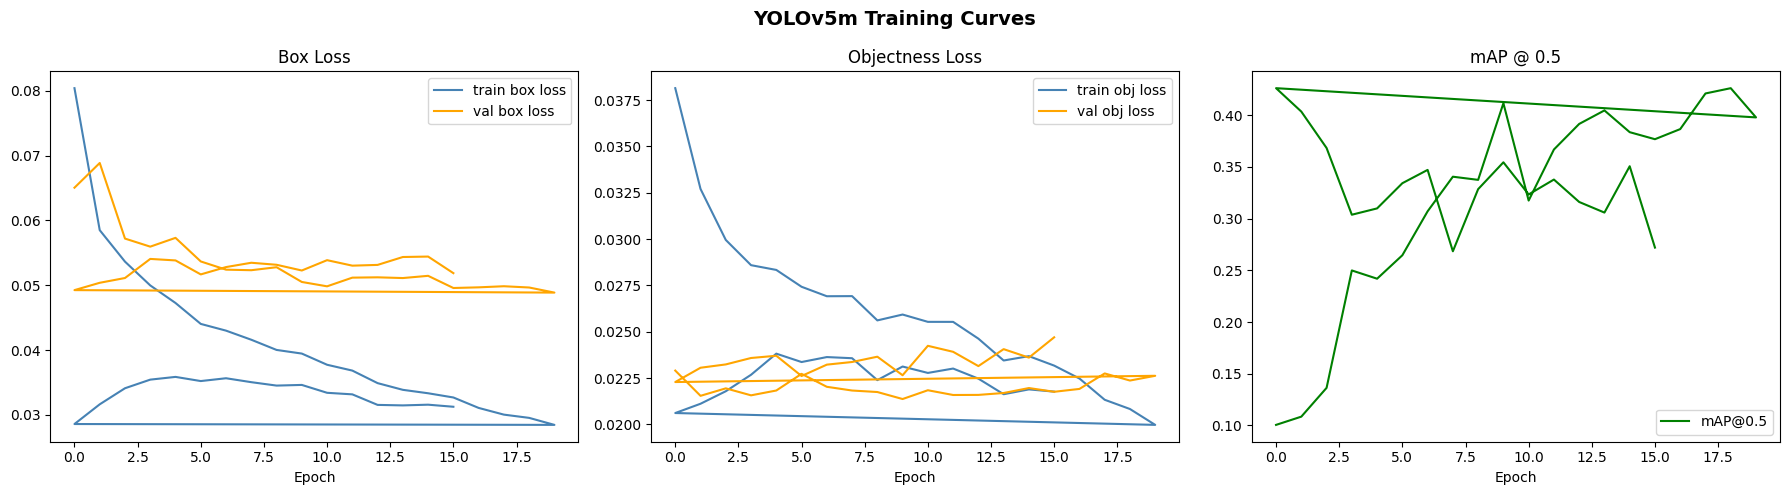

In [16]:
# ── CELL 9: PLOT TRAINING CURVES FROM results.csv ─────────────────────────
# Shows loss curves and mAP over epochs so you can see if the model converged.
# A healthy run: losses decrease, mAP increases and plateaus.

import pandas as pd
import matplotlib.pyplot as plt
import os

RESULTS_CSV = '/content/runs/train/road_damage_garbage/results.csv'

df = pd.read_csv(RESULTS_CSV)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Box loss ──────────────────────────────────────────────────────────────
for col in ['train/box_loss', 'box_loss']:
    if col in df.columns:
        axes[0].plot(df['epoch'], df[col], label='train box loss', color='steelblue')
        break
for col in ['val/box_loss', 'val_box_loss']:
    if col in df.columns:
        axes[0].plot(df['epoch'], df[col], label='val box loss', color='orange')
        break
axes[0].set_title('Box Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

# ── Object loss ───────────────────────────────────────────────────────────
for col in ['train/obj_loss', 'obj_loss']:
    if col in df.columns:
        axes[1].plot(df['epoch'], df[col], label='train obj loss', color='steelblue')
        break
for col in ['val/obj_loss', 'val_obj_loss']:
    if col in df.columns:
        axes[1].plot(df['epoch'], df[col], label='val obj loss', color='orange')
        break
axes[1].set_title('Objectness Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

# ── mAP@0.5 ──────────────────────────────────────────────────────────────
for col in ['metrics/mAP_0.5', 'metrics/mAP50', 'mAP_0.5']:
    if col in df.columns:
        axes[2].plot(df['epoch'], df[col], label='mAP@0.5', color='green')
        break
axes[2].set_title('mAP @ 0.5'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.suptitle('YOLOv5m Training Curves', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

---
## CELL 10 — Run inference on a random test image

🎲 Randomly selected test image: ds2_img3620_jpg.rf.36410647957f92b4fc6364ded465b85d.jpg
detect: weights=['/content/runs/train/road_damage_garbage/weights/best.pt'], source=/content/combined_dataset/test/images/ds2_img3620_jpg.rf.36410647957f92b4fc6364ded465b85d.jpg, data=yolov5/data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=/content/runs/detect, name=test_infer, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-467-g1d62daa3 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 212 layers, 20873139 parameters, 0 gradients, 47.9 GFLOPs
image 1/1 /content/combined_dataset/test/images/ds2_img3620_jpg.rf.36410647957f92b4fc6364ded465b85d.jpg:

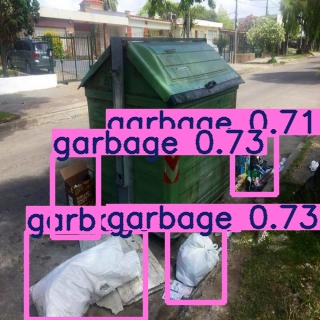

In [18]:
# ── CELL 10: INFERENCE ON RANDOM TEST IMAGE ────────────────────────────────
# Picks a random image from combined_dataset/test/images/
# and runs it through the trained best.pt model.
# Outputs the detected image with bounding boxes drawn.

import os, random
from IPython.display import Image as IPImage, display

TEST_IMG_DIR = '/content/combined_dataset/test/images'
BEST_PT      = '/content/runs/train/road_damage_garbage/weights/best.pt'
INFER_OUT    = '/content/runs/detect/test_infer'
IMG_EXTS     = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# ── Pick a random test image ──────────────────────────────────────────────
all_test_imgs = [
    f for f in os.listdir(TEST_IMG_DIR)
    if os.path.splitext(f)[1].lower() in IMG_EXTS
]
chosen = random.choice(all_test_imgs)
chosen_path = os.path.join(TEST_IMG_DIR, chosen)
print(f'🎲 Randomly selected test image: {chosen}')

# ── Run YOLOv5 detect.py ──────────────────────────────────────────────────
!python /content/yolov5/detect.py \
    --weights  {BEST_PT} \
    --source   {chosen_path} \
    --img      640 \
    --conf     0.25 \
    --iou      0.45 \
    --save-txt \
    --project  /content/runs/detect \
    --name     test_infer \
    --exist-ok

# ── Display the result ────────────────────────────────────────────────────
result_path = os.path.join(INFER_OUT, chosen)
if os.path.exists(result_path):
    print(f'\n✅ Inference result:')
    display(IPImage(filename=result_path, width=800))
else:
    # YOLOv5 sometimes saves as .jpg regardless of input extension
    stem = os.path.splitext(chosen)[0]
    for ext in ['.jpg', '.png', '.jpeg']:
        alt = os.path.join(INFER_OUT, stem + ext)
        if os.path.exists(alt):
            print(f'\n✅ Inference result (saved as {ext}):')
            display(IPImage(filename=alt, width=800))
            break
    else:
        print('⚠️  Could not locate output image. Check /content/runs/detect/test_infer/')

---
## CELL 11 — Download `best.pt`

> Triggers a browser download of your trained model weights. File will be ~50 MB.

In [19]:
# ── CELL 11: DOWNLOAD best.pt ─────────────────────────────────────────────
# Triggers a browser download popup.
# Save it somewhere safe — this is your trained model.

import os
from google.colab import files

BEST_PT = '/content/runs/train/road_damage_garbage/weights/best.pt'

if os.path.exists(BEST_PT):
    size_mb = os.path.getsize(BEST_PT) / 1e6
    print(f'📦 Downloading best.pt ({size_mb:.1f} MB) ...')
    files.download(BEST_PT)
    print('✅ Download triggered — check your browser downloads.')
else:
    print('❌ best.pt not found. Did Cell 7 (training) complete without errors?')

📦 Downloading best.pt (42.3 MB) ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download triggered — check your browser downloads.
